<a href="https://colab.research.google.com/github/mariajuliawm/Estudo-de-manipula-o-de-dados-vetoriais-/blob/main/python_cap5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Capítulo 5: Manipulação de dados vetoriais

In [ ]:
Fenômenos geográficos são características, acontecimentos, objetos ou processos que ocorrem no espaço geográfico e que pode ser medido, observado e representado.
Dividimos os fenômenos em dois grupos:

  a) fenômenos como OBJETOS DISCRETOS: têm limites bem definidos, e podemos contar e separar uma coisa da outra. Exemplos são, escolas, rios, rodovias...
  São objetos que podemos definir onde começa e onde termina.
  São representados por: point, curve, LineString, LinearRing, surface, polygon, Multi -point, -LineString, -Polygon e GeometryCollection (explicados abaixo)

  b) fenômenos como CAMPOS CONTÍNUOS: quando o fenômeno preenche o espaço com valores que variam ponto a ponto.
  Exemplos são temperatura, altitude, polição


In [ ]:
Representamos estes fenômenos por meio de:

  a) Representação matricial (raster):
  - usado para fenômenos contínuos
  - o espaço é dividido em pixels (que são organizados em linhas e colunas) e cada célula armazena um valor numérico que representa a informação naquela localização.
  - resolução espacial é o tamanho da célula, quanto menor a célula, mais detalhes.

  b) Representação vetorial:
  - usada para objetos discretos
  - o espaço é representado por objetos geométricos definidos por coordenadas (x,y). Cada objeto pode ser um ponto, uma linha ou um polígono.
  - cada objeto é independente e pode ser selecionado individualmente.
  - Feição (ou feature) é um objeto geográfico vetorial. Cada um destes elementos possui uma geometria (forma e localização no espaço) e atributos alfanuméricos
  (informações descritivas).
  "ce n'est pas pipe": a feição é a representação digital de um objeto real. Uma mesma coisa real pode ser represetada de formas diferentes, dependendo da escala,
  propósito, disponibilidade de dados. ex: uma cidade pode ser representada por um ponto (em um mapa de pequena escala) ou por um polígono (em um mapa de grande escala).
  As feições são organizadas em coleções que compartilham uma mesma estrutura de atributos (nome das colunas nas tabelas)
  Exemplo: cada estado brasileiro é uma feição, sua geometria é um poligono e seus atributos são o nome do estado, população, área, etc.
  esquemas:    atributos        tipo            exemplo
               uf_id            int             35
               nome             str             "São Paulo"
               população        int             44411238
               exp_de_vida      float           76.4
               fronteira        multipolygon


In [ ]:
Depois que criamos um mapa com pontos, linhas e polígonos, cada mapa vira um arquivo. Formatos de arquivo utilizadas:
  a) Para dados vetoriais:
      - Shapefile (na verdade é um grupo de arquivos com extensões .shp, .shx, .dbf etc.)
      - GeoJSON (um único arquivo de texto, muito usado na internet)
      - KML (usado no Google Earth)
  b) Para dados matriciais:
      - GeoTIFF (uma imagem de satélite ou mapa de altitude)
      - JPEG, PNG (mas sem informações geográficas, só a imagem)
  c) Banco de dados:
      - PostgreSQL com extensão PostGIS (muito usado)
      - MySQL (com extensão espacial)
      - SQL Server, Oracle (também têm opções espaciais)

In [ ]:
# Tipos geométricos

In [ ]:
  # Modelos geométricos

In [ ]:
OPEN GEOSPATIAL CONSORTIUM SIMPLE FEATURES (abnt deles, aparentemente) padronizou:

a) Os tipos geométricos:

Geometrias básicas:
  - Point: é uma localização exata, com coordenadas x e y e sem dimensão nem borda. (ex: doenças registradas)
  - Curve : é um traço entre dois pontos, tem comprimento e podem ter as dimensões z (altitude) e m (medida - comprimento)
  - Surface: representa objetos com área (comprimento e largura). (ex: unidade de conservação)

Subclasses concretas:
  - LineString: é um tipo de linha formado por uma sequência de pontos ligados em sequência. A fronteira desta linha - nomeada fronteira aberta - é definida pelo start e end point, os pontos intermediários
  não compõe a borda.
  - LinearRing: é um tipo de linha formada quando o start e end point coincidem. A fronteira desta linha - nomeada fronteira fechada - é um conjunto vazio.
  - Polygon: é uma subclasse de surface. É um tipo de área delimitada por uma ou mais linhas. é formado, obrigatóriamente, por um anel externo (borda principal),
  e poder ter anéis internos (buracos dentro do poligono) (ex: uma ilha com um grande lago)

Coleções geométricas:
  - Multi -point, -LineString, -Polygon: são coleções de pontos, linhas e polígonos, respectivamente.
  - GeometryCollection: mistura de ponto, linha e polígono

b) Os relacionamentos espaciais:
 Como os sistemas de computação definem a relação entre objetos (ou duas geometrias):
 A base é a # Matriz de 9-Intersecções Estendida Dimensionalmente (DE-9IM).
   Exemplo: Quero saber se se um rio crusa uma cidade, mas o computador só entemde números e coordenadas. O DE-9IM é um método matemático para resolver este problema.
  A ideia é o computador analisará tres partes de cada objeto em questão para concluir se as partes se encontram:
    - Inferior: corpo do objeto
    - Fronteira: borda do obeto
    - Exterior: o que está de fora do objeto

  A DE-9IM organiza estas perguntas numa matriz 3 x 3:

                  INTERIOR DE B       FRONTEIRA DE B       EXTERIOR DE B

INTERIOR DE A     I(A) ∩ I(B)         I(A) ∩ F(B)          I(A) ∩ E(B)

FRONTEIRA DE A    F(A) ∩ I(B)         F(A) ∩ F(B)          F(A) ∩ E(B)

EXTERIOR DE A     E(A) ∩ I(B)         E(A) ∩ F(B)          E(A) ∩ E(B)

E as respostas são dadas por:
-1 ou ∅ -> não há intersecção
0 -> a intersecção é um ponto
1 -> a intersecção é uma linha
2 -> a intersecção é um polígono

exercicio: Tabela 5.7 ( https://prog-geo.github.io/vetorial/tipos-geometricos.html#tbl-vetorial-tipos-geometricos-comp-tipos )


                  INTERIOR DE B       FRONTEIRA DE B       EXTERIOR DE B

INTERIOR DE A       2                     1                    2

FRONTEIRA DE A      1                     0                    1

EXTERIOR DE A       2                     1                    2

Ao invez de montar manuelamente a matriz, podemos utilizar o operador relate:
a = Polygon(((0, 0), (0, 1), (1, 1), (1, 0), (0, 0)))
b = Polygon(((0.5, 0.25), (0.5, 0.75), (0.0, 0.75), (0.0, 0.25), (0.5, 0.25)))
matriz = relate(a, b)
print(matriz) # 212F11FF2

E para conferir uma string resposta:
resultado = a.relate_pattern(b, "212F11FF2")
print(resultado) # True



c) As operações espaciais: como testar os relacionamentos espaciais
Com o OGC-SFS, todos os sistemas geoespaciais (PostGIS, QGIS, GeoPandas, etc.) passaram a usar as mesmas definições:
O padrão OGC-SFS define 8 operadores nomeados que encapsulam padrões comuns da DE-9IM:
  - Equals: são geometricamente identicos
  - Disjoint: não se tocam
  - Intersects: se tocam
  - Touches: as bordas se tocam
  - Crosses: Se cruzam. A intersecção tem uma dimensão menor que a maior das geometrias
  - Within: A geometria B está dentro da geometria A
  - Contains: A geometria A contém a geometria B
  - Overlaps: Se sobrepõem parcialmente, resultando em uma geometria da mesma dimensão

O computador responde as perguntas com:

T: Dimensão 0, 1 ou 2 (há intersecção).
F: Dimensão -1 (não há intersecção).
*: Não importa.
0, 1, 2: A dimensão exata da intersecção.

In [ ]:
from shapely.geometry import Polygon

a = Polygon(((0, 0), (0, 1), (1, 1), (1, 0), (0, 0)))
b = Polygon(((0.5, 0.25), (0.5, 0.75), (0.0, 0.75), (0.0, 0.25), (0.5, 0.25)))
matriz = a.relate(b)
print(matriz)

212F11FF2


In [ ]:
# Pergunta: A e B têm a relação?
resultado = a.relate_pattern(b, "212F11FF2")
print(resultado)

True


In [ ]:
  # Tipos geométricos em python:
A shapely é uma biblioteca que implementa o padrão OGS-SFS

In [ ]:
import shapely

In [ ]:
# a) Para criar objetos do tipo Point:
from shapely.geometry import Point
ponto = Point(1, 3)
print(ponto.x) # acessa a coordenada x
print(ponto.y) # acessa a coordenada y

1.0
3.0


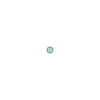

In [ ]:
ponto

In [ ]:
# b) Para criar objetos do tipo LineString:
from shapely.geometry import LineString
linha = LineString([(0, 0), (1, 1), (2, 0)])
print(linha.length) # comprimento da linha
print(linha.boundary) # fronteiras, ponto inicial e final
print(linha.coords[0:2]) # acessa os dois primeiros pontos


2.8284271247461903
MULTIPOINT ((0 0), (2 0))
[(0.0, 0.0), (1.0, 1.0)]


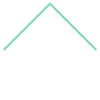

In [ ]:
linha # desenha a imagem

In [ ]:
#c) Para criar objetos do tipo LinearRing
from shapely.geometry import LinearRing
anel = LinearRing( [ (0, 0), (10, 0), (10, 10), (0, 10), (0, 0) ] )
print(anel.length) # comprimento do perímetro
print(anel.boundary) # não tem fronteira, conjunto vazio, logo também não tem área

40.0
MULTIPOINT EMPTY


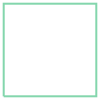

In [ ]:
anel # desenha a imagem


In [ ]:
# d) Para criar objetos do tipo Polígonos:
# O construtor de um objeto Polygon aceita dois argumentos. O primeiro, obrigatório, é uma sequência de tuplas (x, y) ou (x, y, z) que representa o anel externo do polígono.
# O segundo, opcional, é uma sequência de anéis e representa os anéis internos do polígono:
from shapely.geometry import Polygon
anel_externo = [ (0, 0), (10, 0), (10, 10), (0, 10), (0, 0) ]
anel_interno = [ (3, 3), (7, 3), (7, 7), (3, 7), (3, 3) ]
poligono = Polygon(anel_externo, [anel_interno])

print(poligono.exterior) # perímetro externo
print(len(poligono.interiors)) # perímetro interno
print(poligono.area)  # área (externa menos interna)
print(poligono.length)  # perímetro (externo + interno)
print(poligono.boundary) # fronteira = ambos os anéis


LINEARRING (0 0, 10 0, 10 10, 0 10, 0 0)
1
84.0
56.0
MULTILINESTRING ((0 0, 10 0, 10 10, 0 10, 0 0), (3 3, 7 3, 7 7, 3 7, 3 3))


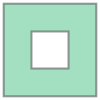

In [ ]:
poligono

In [ ]:
# e) Para criar objetos do tipo MultiPoint:
from shapely.geometry import MultiPoint
mpt = MultiPoint( [ (0, 0), (5, 5), (10, 0), (10, 10), (0, 10) ] )
for pt in mpt.geoms:       # acessa cada ponto individual
    print(pt.x, pt.y)



0.0 0.0
5.0 5.0
10.0 0.0
10.0 10.0
0.0 10.0


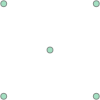

In [ ]:
mpt

In [ ]:
# f) Para criar objetos do tipo MultiLineString:
from shapely.geometry import MultiLineString
mls = MultiLineString( [ [ (0, 0), (8, 2), (13, 9) ],
                           [ (21, 11), (30, -1) ] ])
print(mls)
print(mls.length) # soma dos comprimentos
print(mls.boundary) # pontos inicial e final de cada linha

MULTILINESTRING ((0 0, 8 2, 13 9), (21 11, 30 -1))
31.848536518277946
MULTIPOINT ((0 0), (13 9), (21 11), (30 -1))


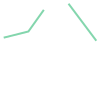

In [ ]:
mls

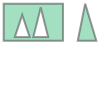

In [ ]:
# g) Para criar objetos do tipo MultiPolygon:
from shapely.geometry import MultiPolygon
mpoly = MultiPolygon([ [ [ (0, 0), (16, 0), (16, 10), (0, 10), (0, 0) ], [ [ (3, 1), (7, 1), (5, 7), (3, 1) ], [ (8, 1), (12, 1), (10, 9), (8, 1) ] ] ], [
    [ (20, 0), (25, 0), (22, 10), (20, 0) ],] ] )
mpoly


In [ ]:
print(mpoly.length)
print(mpoly.area) # soma das áreas
print(mpoly.boundary)

114.77987867924028
157.0
MULTILINESTRING ((0 0, 16 0, 16 10, 0 10, 0 0), (3 1, 7 1, 5 7, 3 1), (8 1, 12 1, 10 9, 8 1), (20 0, 25 0, 22 10, 20 0))


In [ ]:
# g) Podemos escrever de maneira mais clara:
from shapely.geometry import MultiPolygon

# definição do primeiro poligono:
shell_1 = LinearRing( [ (0, 0), (16, 0), (16, 10), (0, 10), (0, 0) ] ) # me da o contorno retangular
hole_1 = LinearRing( [ (3, 1), (7, 1), (5, 7), (3, 1) ] ) # me da um dos triangulos internos
hole_2 = LinearRing( [ (8, 1), (12, 1), (10, 9), (8, 1) ] ) # da o outro triangulo
poly_1 = Polygon( shell_1, [ hole_11, hole_12 ] )
# definição do segundo polígono
shell_2 = LinearRing( [ (20, 0), (25, 0), (22, 10), (20, 0) ] )
poly_2 = Polygon(shell_2)
sell_2

#definição de ambos poligonos como um:
mpoly = MultiPolygon([poly_1, poly_2])

In [ ]:
# Relacionamentos Espaciais. O Shapely implementa todos os operadores nomeados:

pt = Point(2, 3)
line = LineString([(1, 1), (0, 3), (4, 3)])

# Operador Relate
print(pt.relate(line))           # retorna a string da matriz DE-9IM
print(line.relate(pt))           # mesma relação, ordem invertida

# Operadores nomeados
print(line.contains(pt))         # A linha contém o ponto?
print(line.touches(pt))          # A linha toca o ponto?
print(line.crosses(pt))          # A linha cruza o ponto?
print(line.intersects(pt))       # A linha intersecta o ponto?
print(line.equals(pt))           # A linha é igual ao ponto?

# Com polígono
poly = Polygon([(1, 2), (1, 4), (3, 4), (3, 2)])
print(line.relate(poly))         # retorna a string da matriz DE-9IM
print(line.intersects(poly))     # A linha intersecta o polígono?
print(line.crosses(poly))        # A linha cruza o polígono?

0FFFFF102
0F1FF0FF2
True
False
False
True
False
101FF0212
True
True


In [ ]:
# Operações de Conjuntos
São as operações que combinam duas geometrias para criar uma nova geometria:

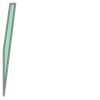

In [ ]:
# a) intersection: a imagem resultante é a região que as duas figuras se sobrepo
from shapely.geometry import Polygon
quadrado1 = Polygon([(0, 0), (10, 0), (3, 3), (0, 3)])
triangulo = Polygon([(1, 1), (2, 9), (1, 2)])
intersecao = quadrado1.intersection(triangulo)
intersecao

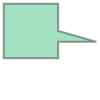

In [ ]:
# b) union: a imagem resultante é a extensão de ambos poligonos juntos.
from shapely.geometry import Polygon
quadrado1 = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])
triangulo = Polygon([(3, 3), (17, 3), (3, 7)])
uniao = quadrado1.union(triangulo)
uniao


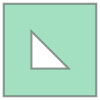

In [ ]:
# c) difference: a parte que esta em a, mas não esta em b.
from shapely.geometry import Polygon
quadrado = Polygon([(0, 0), (10, 0), (10, 10), (0, 10)])
triangulo = Polygon([(3, 3), (7, 3), (3, 7)])
diferenca = quadrado.difference(triangulo)
diferenca

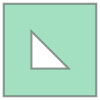

In [ ]:
# d) symmetric_difference: são as partes exclusivas de cada um
symmetric_difference = quadrado.symmetric_difference(triangulo)
symmetric_difference


In [ ]:
#pyproj
import pyproj

In [ ]:
help(pyproj)

In [ ]:
# 01/04: manipulação de dados matriciais usando a rasterio
import rasterio as rio
with rio.open('nome de um arquivo que exista', 'r') as dataset: # r para read e não alterar o arquivo
  matriz = dataset.read(1) #algo sobre canais
  print(f"Número de linhas/colunas: {dataset.shape}")
  print(f"Valor para nodata: {dataset.nodata}") # pixels que não valem nada


In [ ]:
# manipulação de números usando NumPy
import numpy as np
# matriz é uma variável do tipo numpy
print(f"Pixel na posição 6000, 400: {matriz[6000, 400]}")
print(f"Estatísticas da matriz original: \
        {matriz.min()}, {matriz.max()}}, \
        {matriz.mean()}, {matriz.std()}")
# modificar todos os valores da matriz (ex de aplicação: mudança da cor da imagem)
matriz = matriz * 2


In [ ]:
pyproj
shapely